In [1]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import numpy as np

# Configuración de visualización
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Análisis Exploratorio de Datos - SpyGame

## Objetivo
Analizar los datos de usuarios y sesiones del juego SpyGame, expandiendo las listas de hints y guesses para crear un dataset donde cada fila representa un hint individual y su guess correspondiente.

## 1. Carga de Datos

In [2]:
# Cargar datos de usuarios

users_data = []
with open('data/20260122_users.json', 'r', encoding='utf-8') as f:
    for line in f:
        users_data.append(json.loads(line))

df_users = pd.DataFrame(users_data)
print(f"Usuarios cargados: {len(df_users)}")
df_users.head()

Usuarios cargados: 21


,_id,username,password,created_at,knowledge_profile
0,{'$oid': '6939256cfdc2050a76d917ab'},alonso02_rupa,pbkdf2:sha256:600000$pxJ8uj5yhkiMMLMt$c7172e6d...,2025-12-10T07:46:52.028633,NaN
1,{'$oid': '693ff061fdc2050a76d91834'},TrialUser,pbkdf2:sha256:600000$SOQ3KCR43TOBpTfQ$92e7291c...,2025-12-15T11:26:25.480719,"{'cultura_general': 1, 'geografia': 1, 'actual..."
2,{'$oid': '694275fbfdc2050a76d918a4'},juanmooreno,pbkdf2:sha256:600000$JGg9LcjMVC0joqqo$da9b6bec...,2025-12-17T09:20:59.715241,"{'cultura_general': 4, 'geografia': 4, 'actual..."
3,{'$oid': '694288d2fdc2050a76d918d3'},Laura,pbkdf2:sha256:600000$EM1kxTKWgjgbyEZZ$169e1370...,2025-12-17T10:41:22.429533,"{'cultura_general': 2, 'geografia': 1, 'actual..."
4,{'$oid': '6942aefbeb6a8ac082995c19'},danielpenap,pbkdf2:sha256:600000$E7ybAm8RI73SZhlC$0ad408cd...,2025-12-17T13:24:11.904695,"{'cultura_general': 4, 'geografia': 2, 'actual..."


In [3]:
# Cargar datos de sesiones
sessions_data = []
with open('data/20260122_sessions.json', 'r', encoding='utf-8') as f:
    for line in f:
        sessions_data.append(json.loads(line))

df_sessions = pd.DataFrame(sessions_data)
print(f"Sesiones cargadas: {len(df_sessions)}")
df_sessions.head()

Sesiones cargadas: 789


,_id,session_id,person,pista,guesses,acierto,timestamp,last_updated,username,pistas_order
0,{'$oid': '6939256efdc2050a76d917ae'},c6ddb155-7d63-49f9-b8d4-6b3ba1a850a2,Ludwig van Beethoven,[Padeció saturnismo debido a la ingesta de agu...,"[, , , ]",False,2025-12-10T07:46:54.606466,2025-12-10T07:48:31.561403,alonso02_rupa,NaN
1,{'$oid': '693925d0fdc2050a76d917bf'},b159588d-07f5-4465-b6e2-4639cc17b6f8,Mahatma Gandhi,[Fue influenciado por la correspondencia con L...,"[, , ]",False,2025-12-10T07:48:32.886584,2025-12-10T07:48:37.983897,alonso02_rupa,NaN
2,{'$oid': '693927d0fdc2050a76d917cd'},587ba249-91b7-4487-8dc8-dfd568efe190,Charles Chaplin,[Fue cofundador de la compañía de distribución...,[],False,2025-12-10T07:57:04.046292,2025-12-10T07:57:11.312833,alonso02_rupa,NaN
3,{'$oid': '69392907fdc2050a76d917d5'},9c8e5d97-6687-48ac-bd6e-243825d7aad0,Winston Churchill,[Fue un prolífico pintor y ganador del Premio ...,"[, , , ]",False,2025-12-10T08:02:15.763960,2025-12-10T08:02:30.081922,NaN,NaN
4,{'$oid': '69395279fdc2050a76d917e5'},c7738018-5252-4488-993f-213ed16a142a,Galileo Galilei,[Descubrió la ley de la isocronismo de los pén...,"[Prueba123, Nose, Galileo]",True,2025-12-10T10:59:05.303307,2025-12-10T10:59:23.786848,alonso02_rupa,NaN


## 2. Exploración Inicial - Usuarios

In [4]:
# Información general de usuarios
print("=== Información del Dataset de Usuarios ===")
print(f"\nShape: {df_users.shape}")
print(f"\nColumnas: {df_users.columns.tolist()}")
print(f"\nTipos de datos:")
print(df_users.dtypes)
print(f"\nValores nulos:")
print(df_users.isnull().sum())

=== Información del Dataset de Usuarios ===

Shape: (21, 5)

Columnas: ['_id', 'username', 'password', 'created_at', 'knowledge_profile']

Tipos de datos:
_id                  object
username             object
password             object
created_at           object
knowledge_profile    object
dtype: object

Valores nulos:
_id                  0
username             0
password             0
created_at           0
knowledge_profile    6
dtype: int64


In [5]:
# Usuarios con perfil de conocimiento completado
users_with_profile = df_users['knowledge_profile'].notna().sum()
print(f"Usuarios con perfil de conocimiento: {users_with_profile} / {len(df_users)}")
print(f"Porcentaje: {users_with_profile/len(df_users)*100:.2f}%")

Usuarios con perfil de conocimiento: 15 / 21
Porcentaje: 71.43%


## 3. Exploración Inicial - Sesiones

In [6]:
# Información general de sesiones
print("=== Información del Dataset de Sesiones ===")
print(f"\nShape: {df_sessions.shape}")
print(f"\nColumnas: {df_sessions.columns.tolist()}")
print(f"\nTipos de datos:")
print(df_sessions.dtypes)
print(f"\nValores nulos:")
print(df_sessions.isnull().sum())

=== Información del Dataset de Sesiones ===

Shape: (789, 10)

Columnas: ['_id', 'session_id', 'person', 'pista', 'guesses', 'acierto', 'timestamp', 'last_updated', 'username', 'pistas_order']

Tipos de datos:
_id             object
session_id      object
person          object
pista           object
guesses         object
acierto           bool
timestamp       object
last_updated    object
username        object
pistas_order    object
dtype: object

Valores nulos:
_id               0
session_id        0
person            0
pista             0
guesses           0
acierto           0
timestamp         0
last_updated      0
username        476
pistas_order    104
dtype: int64


In [7]:
# Análisis básico de sesiones
print("=== Análisis Básico de Sesiones ===")
print(f"\nSesiones con acierto: {df_sessions['acierto'].sum()}")
print(f"Sesiones sin acierto: {(~df_sessions['acierto']).sum()}")
print(f"Tasa de acierto: {df_sessions['acierto'].mean()*100:.2f}%")
print(f"\nPersonajes únicos: {df_sessions['person'].nunique()}")
print(f"\nTop 10 personajes más jugados:")
print(df_sessions['person'].value_counts().head(10))

=== Análisis Básico de Sesiones ===

Sesiones con acierto: 552
Sesiones sin acierto: 237
Tasa de acierto: 69.96%

Personajes únicos: 45

Top 10 personajes más jugados:
person
Winston Churchill    41
Mahatma Gandhi       40
Vladimir Putin       40
Galileo Galilei      38
Isaac Newton         36
Buda Gautama         36
Iosif Stalin         35
Pablo Picasso        35
Dante Alighieri      34
Leonardo da Vinci    34
Name: count, dtype: int64


## 4. Explotación de Listas: Hints y Guesses

Ahora vamos a expandir las listas `pista` (hints) y `guesses` de forma que cada fila represente un hint individual con su guess correspondiente.

In [8]:
# Función para expandir hints y guesses
def expand_hints_guesses(df):
    """
    Expande las listas de hints (pista) y guesses de forma que cada fila
    represente un hint individual con su guess correspondiente.
    """
    expanded_rows = []
    
    for idx, row in df.iterrows():
        session_id = row['session_id']
        person = row['person']
        acierto = row['acierto']
        username = row.get('username', None)
        timestamp = row.get('timestamp', None)
        last_updated = row.get('last_updated', None)
        
        hints = row['pista']
        guesses = row['guesses']
        
        # Asegurarse de que guesses tenga la misma longitud que hints
        # (rellenar con valores vacíos si es necesario)
        num_hints = len(hints)
        num_guesses = len(guesses)
        
        # Extender guesses si es más corto
        if num_guesses < num_hints:
            guesses = guesses + [''] * (num_hints - num_guesses)
        
        # Crear una fila por cada hint
        for hint_num, (hint, guess) in enumerate(zip(hints, guesses), start=1):
            expanded_rows.append({
                'session_id': session_id,
                'person': person,
                'username': username,
                'acierto': acierto,
                'hint_number': hint_num,
                'total_hints': num_hints,
                'hint': hint,
                'guess': guess,
                'guess_not_empty': guess != '',
                'timestamp': timestamp,
                'last_updated': last_updated
            })
    
    return pd.DataFrame(expanded_rows)

# Expandir el dataset
df_expanded = expand_hints_guesses(df_sessions)
print(f"Dataset original: {len(df_sessions)} sesiones")
print(f"Dataset expandido: {len(df_expanded)} filas (hint-guess pairs)")
print(f"\nPrimeras filas del dataset expandido:")
df_expanded.head(10)

Dataset original: 789 sesiones
Dataset expandido: 2293 filas (hint-guess pairs)

Primeras filas del dataset expandido:


,session_id,person,username,acierto,hint_number,total_hints,hint,guess,guess_not_empty,timestamp,last_updated
0,c6ddb155-7d63-49f9-b8d4-6b3ba1a850a2,Ludwig van Beethoven,alonso02_rupa,False,1,5,Padeció saturnismo debido a la ingesta de agua...,,False,2025-12-10T07:46:54.606466,2025-12-10T07:48:31.561403
1,c6ddb155-7d63-49f9-b8d4-6b3ba1a850a2,Ludwig van Beethoven,alonso02_rupa,False,2,5,Su muerte se atribuye a una insuficiencia hepá...,,False,2025-12-10T07:46:54.606466,2025-12-10T07:48:31.561403
2,c6ddb155-7d63-49f9-b8d4-6b3ba1a850a2,Ludwig van Beethoven,alonso02_rupa,False,3,5,Compuso treinta y dos sonatas para piano y nue...,,False,2025-12-10T07:46:54.606466,2025-12-10T07:48:31.561403
3,c6ddb155-7d63-49f9-b8d4-6b3ba1a850a2,Ludwig van Beethoven,alonso02_rupa,False,4,5,Su ópera Fidelio es una de sus obras más desta...,,False,2025-12-10T07:46:54.606466,2025-12-10T07:48:31.561403
4,c6ddb155-7d63-49f9-b8d4-6b3ba1a850a2,Ludwig van Beethoven,alonso02_rupa,False,5,5,Fue el último gran representante del clasicism...,,False,2025-12-10T07:46:54.606466,2025-12-10T07:48:31.561403
5,b159588d-07f5-4465-b6e2-4639cc17b6f8,Mahatma Gandhi,alonso02_rupa,False,1,4,Fue influenciado por la correspondencia con Le...,,False,2025-12-10T07:48:32.886584,2025-12-10T07:48:37.983897
6,b159588d-07f5-4465-b6e2-4639cc17b6f8,Mahatma Gandhi,alonso02_rupa,False,2,4,Estudió Derecho en Londres y regresó a la Indi...,,False,2025-12-10T07:48:32.886584,2025-12-10T07:48:37.983897
7,b159588d-07f5-4465-b6e2-4639cc17b6f8,Mahatma Gandhi,alonso02_rupa,False,3,4,Instauró métodos de lucha social novedosos com...,,False,2025-12-10T07:48:32.886584,2025-12-10T07:48:37.983897
8,b159588d-07f5-4465-b6e2-4639cc17b6f8,Mahatma Gandhi,alonso02_rupa,False,4,4,Participó en la Conferencia de Londres en 1931...,,False,2025-12-10T07:48:32.886584,2025-12-10T07:48:37.983897
9,587ba249-91b7-4487-8dc8-dfd568efe190,Charles Chaplin,alonso02_rupa,False,1,2,Fue cofundador de la compañía de distribución ...,,False,2025-12-10T07:57:04.046292,2025-12-10T07:57:11.312833


## 5. Análisis del Dataset Expandido

In [9]:
# Estadísticas del dataset expandido
print("=== Estadísticas del Dataset Expandido ===")
print(f"\nTotal de hint-guess pairs: {len(df_expanded)}")
print(f"Guesses no vacíos: {df_expanded['guess_not_empty'].sum()}")
print(f"Guesses vacíos: {(~df_expanded['guess_not_empty']).sum()}")
print(f"Porcentaje de guesses realizados: {df_expanded['guess_not_empty'].mean()*100:.2f}%")

print("\n=== Distribución por número de hint ===")
print(df_expanded['hint_number'].value_counts().sort_index())

print("\n=== Estadísticas por hint_number ===")
hint_stats = df_expanded.groupby('hint_number').agg({
    'guess_not_empty': ['sum', 'count', 'mean'],
    'session_id': 'nunique'
}).round(3)
hint_stats.columns = ['guesses_realizados', 'total_filas', 'tasa_guess', 'sesiones_unicas']
print(hint_stats)

=== Estadísticas del Dataset Expandido ===

Total de hint-guess pairs: 2293
Guesses no vacíos: 383
Guesses vacíos: 1910
Porcentaje de guesses realizados: 16.70%

=== Distribución por número de hint ===
hint_number
1    789
2    498
3    346
4    239
5    166
6    114
7     83
8     58
Name: count, dtype: int64

=== Estadísticas por hint_number ===
             guesses_realizados  total_filas  tasa_guess  sesiones_unicas
hint_number                                                              
1                            25          789       0.032              789
2                           144          498       0.289              498
3                            69          346       0.199              346
4                            50          239       0.209              239
5                            40          166       0.241              166
6                            23          114       0.202              114
7                            21           83       0.253  

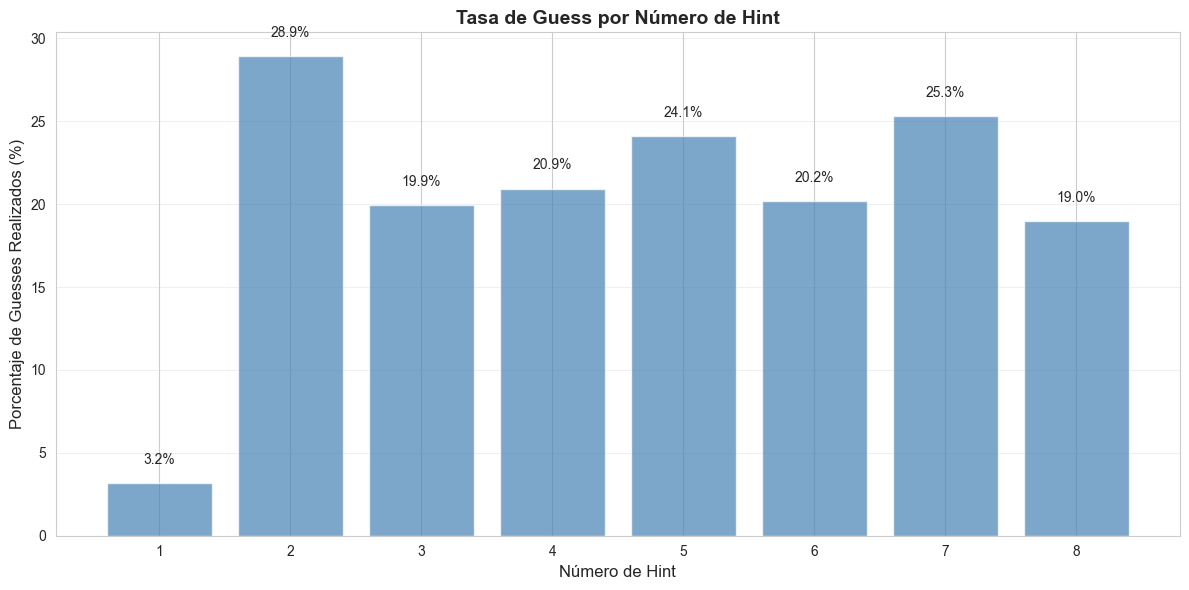

In [10]:
# Visualización: Tasa de guess por número de hint
plt.figure(figsize=(12, 6))
hint_stats_plot = df_expanded.groupby('hint_number')['guess_not_empty'].mean() * 100
plt.bar(hint_stats_plot.index, hint_stats_plot.values, color='steelblue', alpha=0.7)
plt.xlabel('Número de Hint', fontsize=12)
plt.ylabel('Porcentaje de Guesses Realizados (%)', fontsize=12)
plt.title('Tasa de Guess por Número de Hint', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.xticks(hint_stats_plot.index)
for i, v in enumerate(hint_stats_plot.values):
    plt.text(hint_stats_plot.index[i], v + 1, f'{v:.1f}%', ha='center', va='bottom')
plt.tight_layout()
plt.show()

In [11]:
# Análisis de longitud de hints y guesses
df_expanded['hint_length'] = df_expanded['hint'].apply(len)
df_expanded['guess_length'] = df_expanded['guess'].apply(len)

print("=== Estadísticas de Longitud de Hints ===")
print(df_expanded['hint_length'].describe())

print("\n=== Estadísticas de Longitud de Guesses (solo no vacíos) ===")
print(df_expanded[df_expanded['guess_not_empty']]['guess_length'].describe())

=== Estadísticas de Longitud de Hints ===
count    2293.000000
mean       72.267335
std        15.771618
min        25.000000
25%        61.000000
50%        72.000000
75%        83.000000
max       150.000000
Name: hint_length, dtype: float64

=== Estadísticas de Longitud de Guesses (solo no vacíos) ===
count    383.000000
mean       8.775457
std        4.954951
min        3.000000
25%        6.000000
50%        8.000000
75%       11.000000
max       76.000000
Name: guess_length, dtype: float64


## 6. Análisis de Usuarios con Perfil de Conocimiento

In [12]:
# Extraer perfiles de conocimiento
profiles = []
for idx, row in df_users.iterrows():
    if pd.notna(row['knowledge_profile']):
        profile = row['knowledge_profile']
        profile['username'] = row['username']
        profiles.append(profile)

df_profiles = pd.DataFrame(profiles)

# Excluir la columna de timestamp
knowledge_cols = [col for col in df_profiles.columns if col not in ['username', 'profile_completed_at']]

print("=== Estadísticas de Perfiles de Conocimiento ===")
print(f"\nUsuarios con perfil: {len(df_profiles)}")
print(f"\nCategorías de conocimiento:")
print(knowledge_cols)
print("\nEstadísticas descriptivas:")
print(df_profiles[knowledge_cols].describe())

=== Estadísticas de Perfiles de Conocimiento ===

Usuarios con perfil: 15

Categorías de conocimiento:
['cultura_general', 'geografia', 'actualidad_noticias', 'cultura_popular', 'tecnologia_tendencias', 'uso_wikipedia', 'habilidad_busqueda', 'pensamiento_critico']

Estadísticas descriptivas:
       cultura_general  geografia  actualidad_noticias  cultura_popular  \
count        15.000000  15.000000            15.000000        15.000000   
mean          3.200000   3.133333             3.333333         3.466667   
std           1.207122   1.302013             1.234427         1.245946   
min           1.000000   1.000000             1.000000         1.000000   
25%           3.000000   2.500000             3.000000         3.000000   
50%           3.000000   4.000000             4.000000         4.000000   
75%           4.000000   4.000000             4.000000         4.000000   
max           5.000000   5.000000             5.000000         5.000000   

       tecnologia_tendencias  u

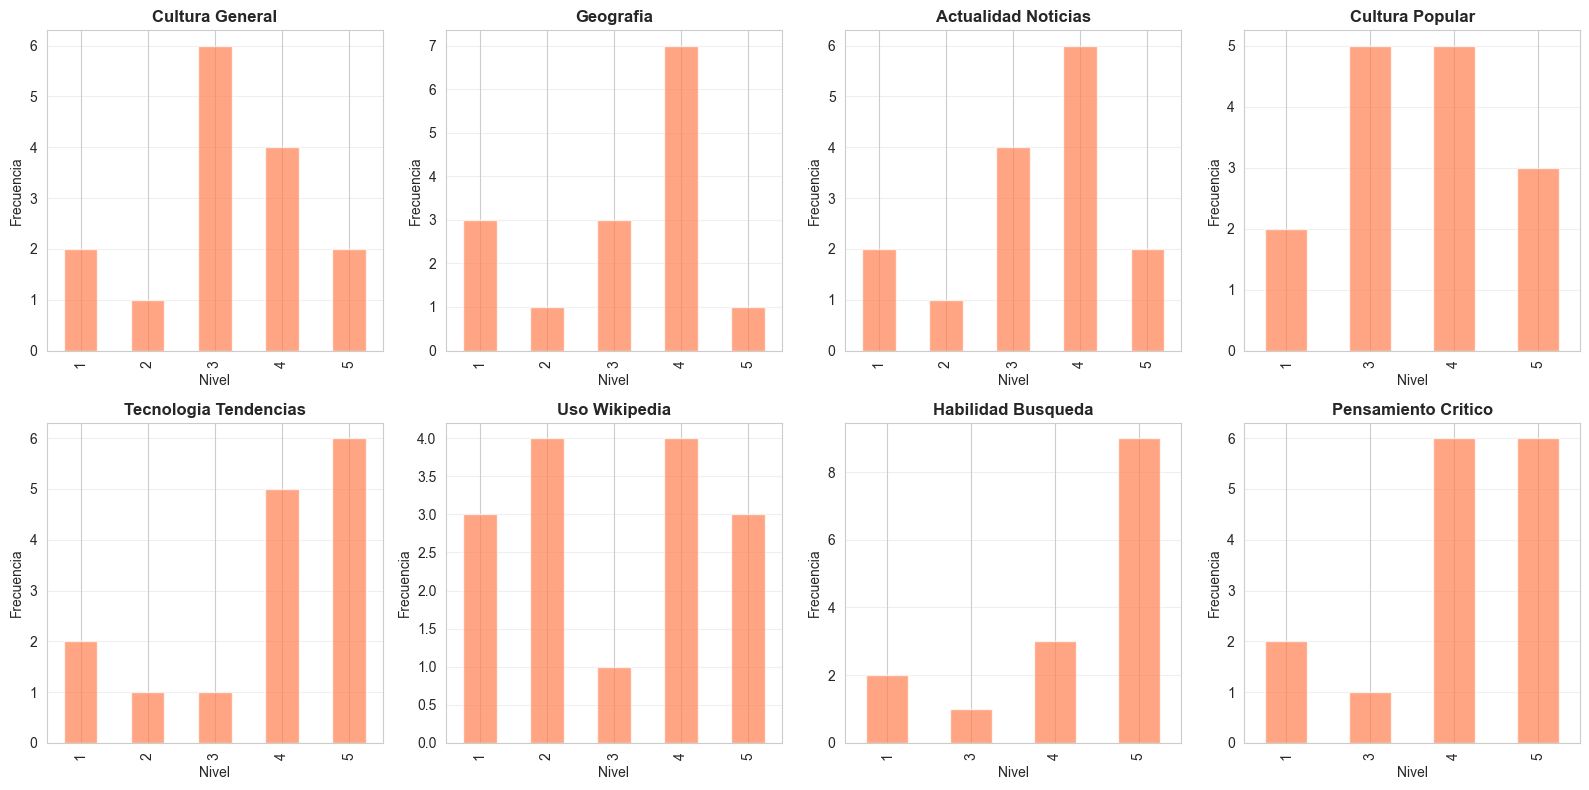

In [13]:
# Visualización de perfiles de conocimiento
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for idx, col in enumerate(knowledge_cols):
    if idx < len(axes):
        df_profiles[col].value_counts().sort_index().plot(kind='bar', ax=axes[idx], color='coral', alpha=0.7)
        axes[idx].set_title(col.replace('_', ' ').title(), fontweight='bold')
        axes[idx].set_xlabel('Nivel')
        axes[idx].set_ylabel('Frecuencia')
        axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Visualizaciones Adicionales

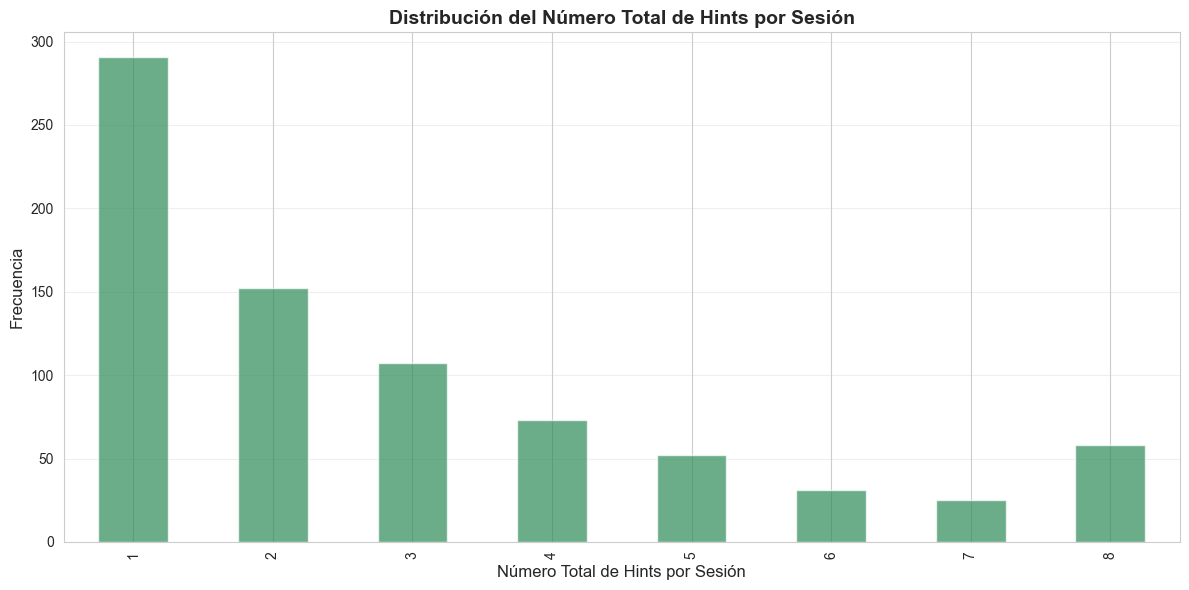


Estadísticas de hints por sesión:
count    789.000000
mean       2.906210
std        2.172468
min        1.000000
25%        1.000000
50%        2.000000
75%        4.000000
max        8.000000
Name: total_hints, dtype: float64


In [14]:
# Distribución de total de hints por sesión
plt.figure(figsize=(12, 6))
df_sessions['total_hints'] = df_sessions['pista'].apply(len)
df_sessions['total_hints'].value_counts().sort_index().plot(kind='bar', color='seagreen', alpha=0.7)
plt.xlabel('Número Total de Hints por Sesión', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.title('Distribución del Número Total de Hints por Sesión', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nEstadísticas de hints por sesión:")
print(df_sessions['total_hints'].describe())

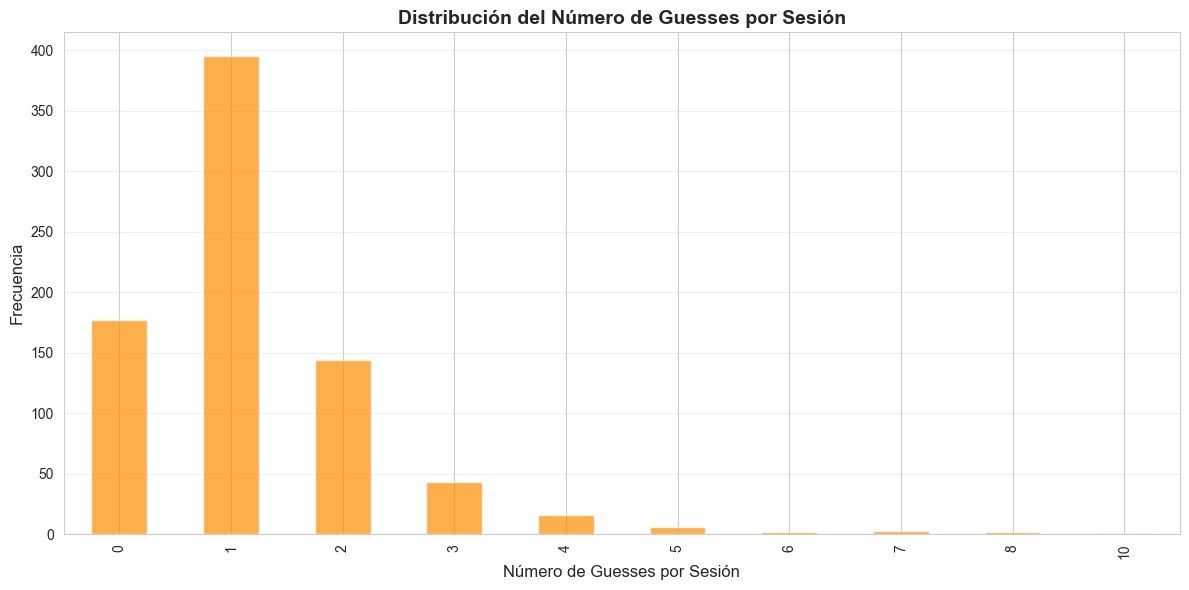


Estadísticas de guesses por sesión:
count    789.000000
mean       1.223067
std        1.143698
min        0.000000
25%        1.000000
50%        1.000000
75%        2.000000
max       10.000000
Name: total_guesses, dtype: float64


In [15]:
# Distribución de guesses por sesión
df_sessions['total_guesses'] = df_sessions['guesses'].apply(lambda x: sum([1 for g in x if g != '']))

plt.figure(figsize=(12, 6))
df_sessions['total_guesses'].value_counts().sort_index().plot(kind='bar', color='darkorange', alpha=0.7)
plt.xlabel('Número de Guesses por Sesión', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.title('Distribución del Número de Guesses por Sesión', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nEstadísticas de guesses por sesión:")
print(df_sessions['total_guesses'].describe())

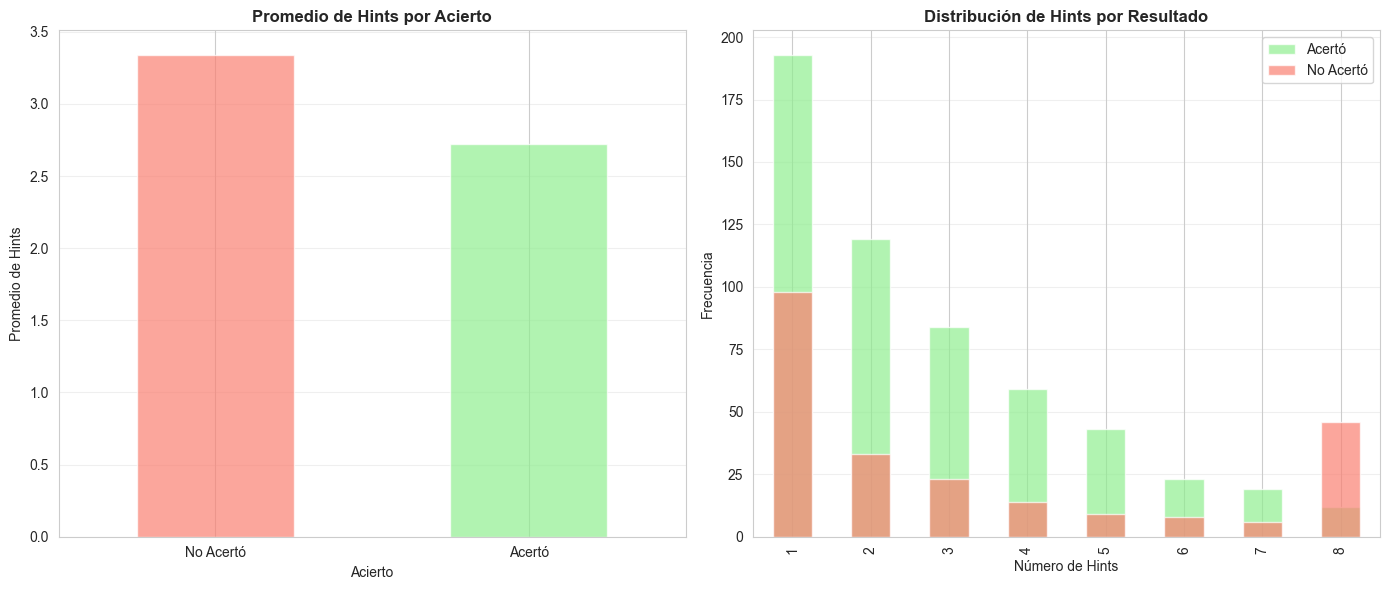

In [16]:
# Relación entre número de hints y acierto
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Por acierto
df_sessions.groupby('acierto')['total_hints'].mean().plot(kind='bar', ax=ax[0], color=['salmon', 'lightgreen'], alpha=0.7)
ax[0].set_title('Promedio de Hints por Acierto', fontweight='bold')
ax[0].set_xlabel('Acierto')
ax[0].set_ylabel('Promedio de Hints')
ax[0].set_xticklabels(['No Acertó', 'Acertó'], rotation=0)
ax[0].grid(axis='y', alpha=0.3)

# Distribución de hints para aciertos vs no aciertos
df_sessions[df_sessions['acierto']]['total_hints'].value_counts().sort_index().plot(
    kind='bar', ax=ax[1], color='lightgreen', alpha=0.7, label='Acertó'
)
df_sessions[~df_sessions['acierto']]['total_hints'].value_counts().sort_index().plot(
    kind='bar', ax=ax[1], color='salmon', alpha=0.7, label='No Acertó'
)
ax[1].set_title('Distribución de Hints por Resultado', fontweight='bold')
ax[1].set_xlabel('Número de Hints')
ax[1].set_ylabel('Frecuencia')
ax[1].legend()
ax[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Exportar Dataset Expandido

In [17]:
# Guardar el dataset expandido
df_expanded.to_csv('results/hints_guesses_expanded.csv', index=False, encoding='utf-8')
print("Dataset expandido guardado en: results/hints_guesses_expanded.csv")
print(f"\nDimensiones: {df_expanded.shape}")
print(f"Columnas: {df_expanded.columns.tolist()}")

Dataset expandido guardado en: results/hints_guesses_expanded.csv

Dimensiones: (2293, 13)
Columnas: ['session_id', 'person', 'username', 'acierto', 'hint_number', 'total_hints', 'hint', 'guess', 'guess_not_empty', 'timestamp', 'last_updated', 'hint_length', 'guess_length']


## 9. Resumen del Análisis

### Datos de Usuarios
- **Total de usuarios**: Cargados desde el archivo JSON
- **Usuarios con perfil de conocimiento**: Analizado en la sección 6
- **Categorías de conocimiento**: cultura_general, geografía, actualidad_noticias, cultura_popular, tecnología_tendencias, uso_wikipedia, habilidad_búsqueda, pensamiento_crítico

### Datos de Sesiones (Original)
- **Total de sesiones**: Cada sesión representa un juego completo
- **Campos principales**: session_id, person, pista (lista), guesses (lista), acierto, username
- **Tasa de acierto global**: Calculada en sección 3

### Dataset Expandido (Hints-Guesses)
- **Transformación**: Cada fila = 1 hint + su guess correspondiente
- **Campos nuevos**: hint_number, total_hints, hint, guess, guess_not_empty
- **Ventaja**: Permite analizar el comportamiento en cada paso del juego
- **Uso**: Ideal para modelos predictivos, análisis de patrones de juego, etc.